# State Injection Experiment

Single-patch state injection workflow via `LogicalExecutor`:
1. `state_injection` — initialize + SE rounds (self-contained)
2. Transversal readout: Z→MZ, X→MX, Y→S_DAG→MX (fault-tolerant)

Works for both **rotated** and **unrotated** surface codes via generic experiment interface.

In [1]:
import sys, os, io, contextlib
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import stim
from experiments.state_injection import StateInjectionExperiment
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig

from src.qec_code.surface_code.rotated import (
    RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock, RotatedSurfaceCodeLogicalOpSet,
)
from src.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock, UnrotatedSurfaceCodeLogicalOpSet,
)

## 1. Rotated Surface Code: Z, X, Y Injection (d=3, rounds=2)

Rotated Z: 15 det, 1 obs


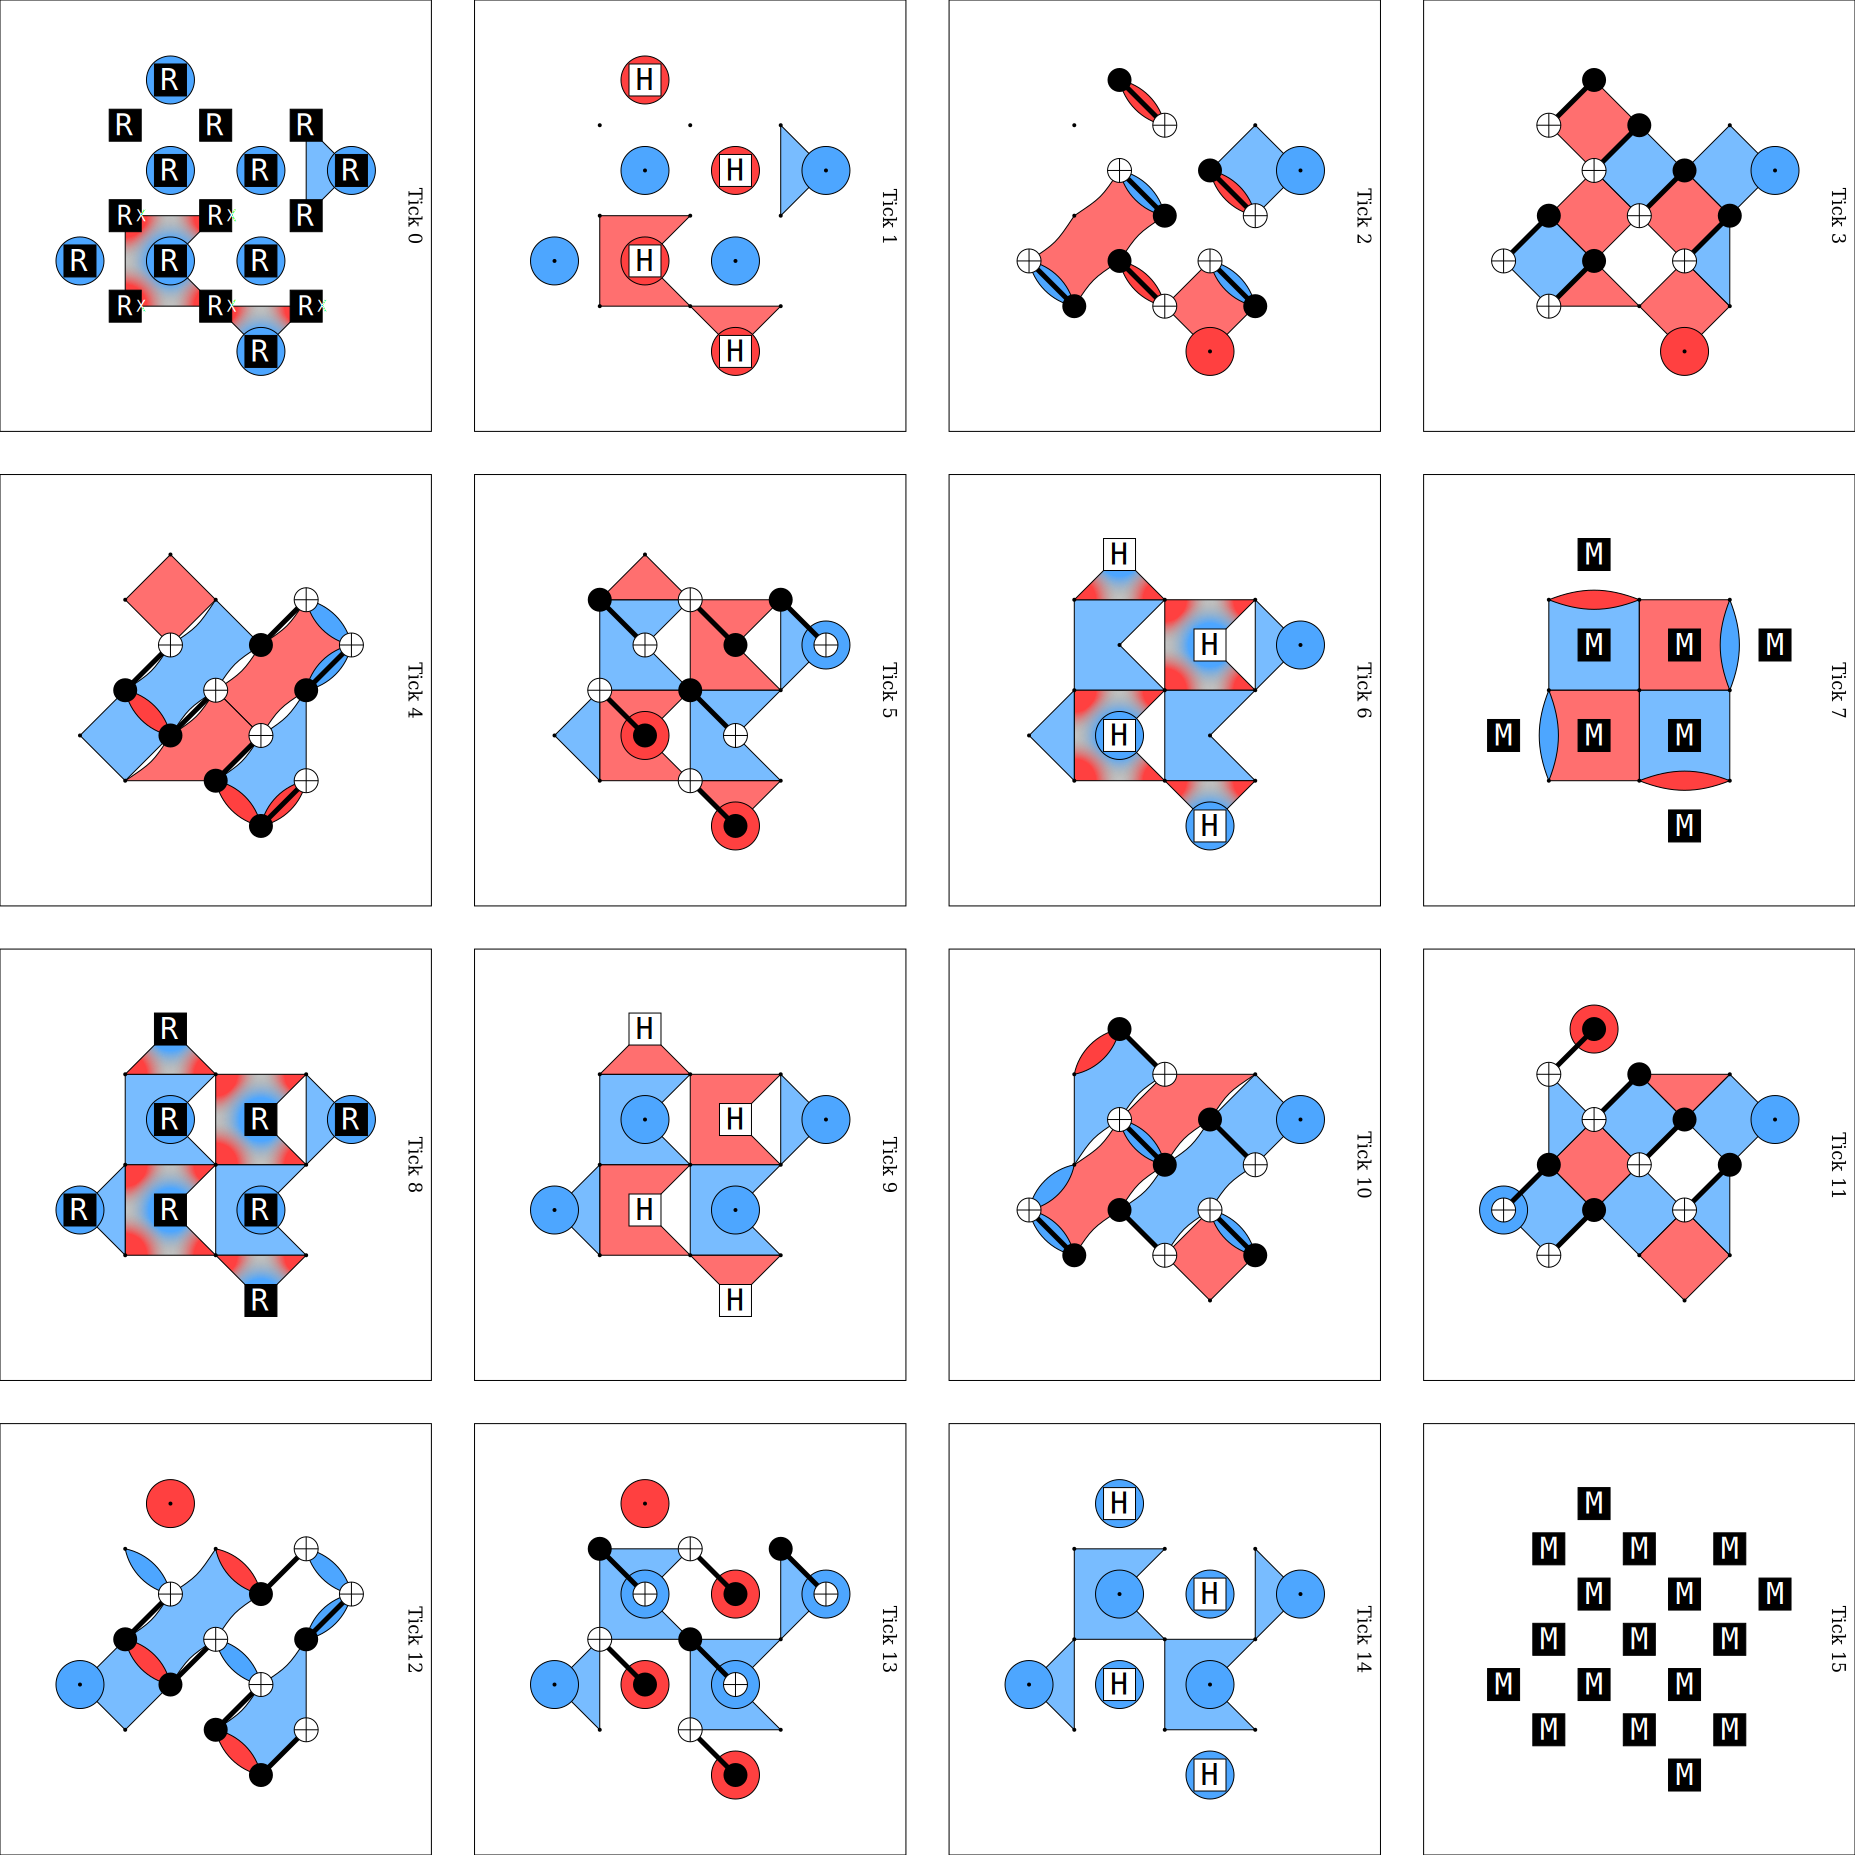

In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    exp_z = StateInjectionExperiment(distance=3, rounds=2, inject_state='Z')
    circuit_z = exp_z.build()
print(f"Rotated Z: {circuit_z.num_detectors} det, {circuit_z.num_observables} obs")
circuit_z.diagram("detslice-with-ops-svg")

In [3]:
circuit_z

stim.Circuit('''
    QUBIT_COORDS(2, 0) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(3, 1) 2
    QUBIT_COORDS(5, 1) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(6, 2) 5
    QUBIT_COORDS(4, 2) 6
    QUBIT_COORDS(1, 3) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(5, 3) 9
    QUBIT_COORDS(0, 4) 10
    QUBIT_COORDS(4, 4) 11
    QUBIT_COORDS(2, 4) 12
    QUBIT_COORDS(1, 5) 13
    QUBIT_COORDS(3, 5) 14
    QUBIT_COORDS(5, 5) 15
    QUBIT_COORDS(4, 6) 16
    RX 7 8 13 14 15
    R 1 2 3 9 0 4 5 6 10 11 12 16
    TICK[SE_start]
    H 0 6 12 16
    TICK
    CX 0 2 6 9 12 14 8 4 13 10 15 11
    TICK
    CX 0 1 6 8 12 13 2 4 7 10 9 11
    TICK
    CX 6 3 12 8 16 15 7 4 9 5 14 11
    TICK
    CX 6 2 12 7 16 14 1 4 3 5 8 11
    TICK
    H 0 6 12 16
    TICK
    M 0 4 5 6 10 11 12 16
    DETECTOR[post-select](6, 2, 0) rec[-6]
    DETECTOR[post-select](2, 4, 0) rec[-2]
    DETECTOR[post-select](4, 6, 0) rec[-1]
    REPEAT 1 {
        TICK
        R 0 4 5 6 10 11 12 16
        TICK[SE_start]
        H 0 6

Rotated X: 15 det, 1 obs


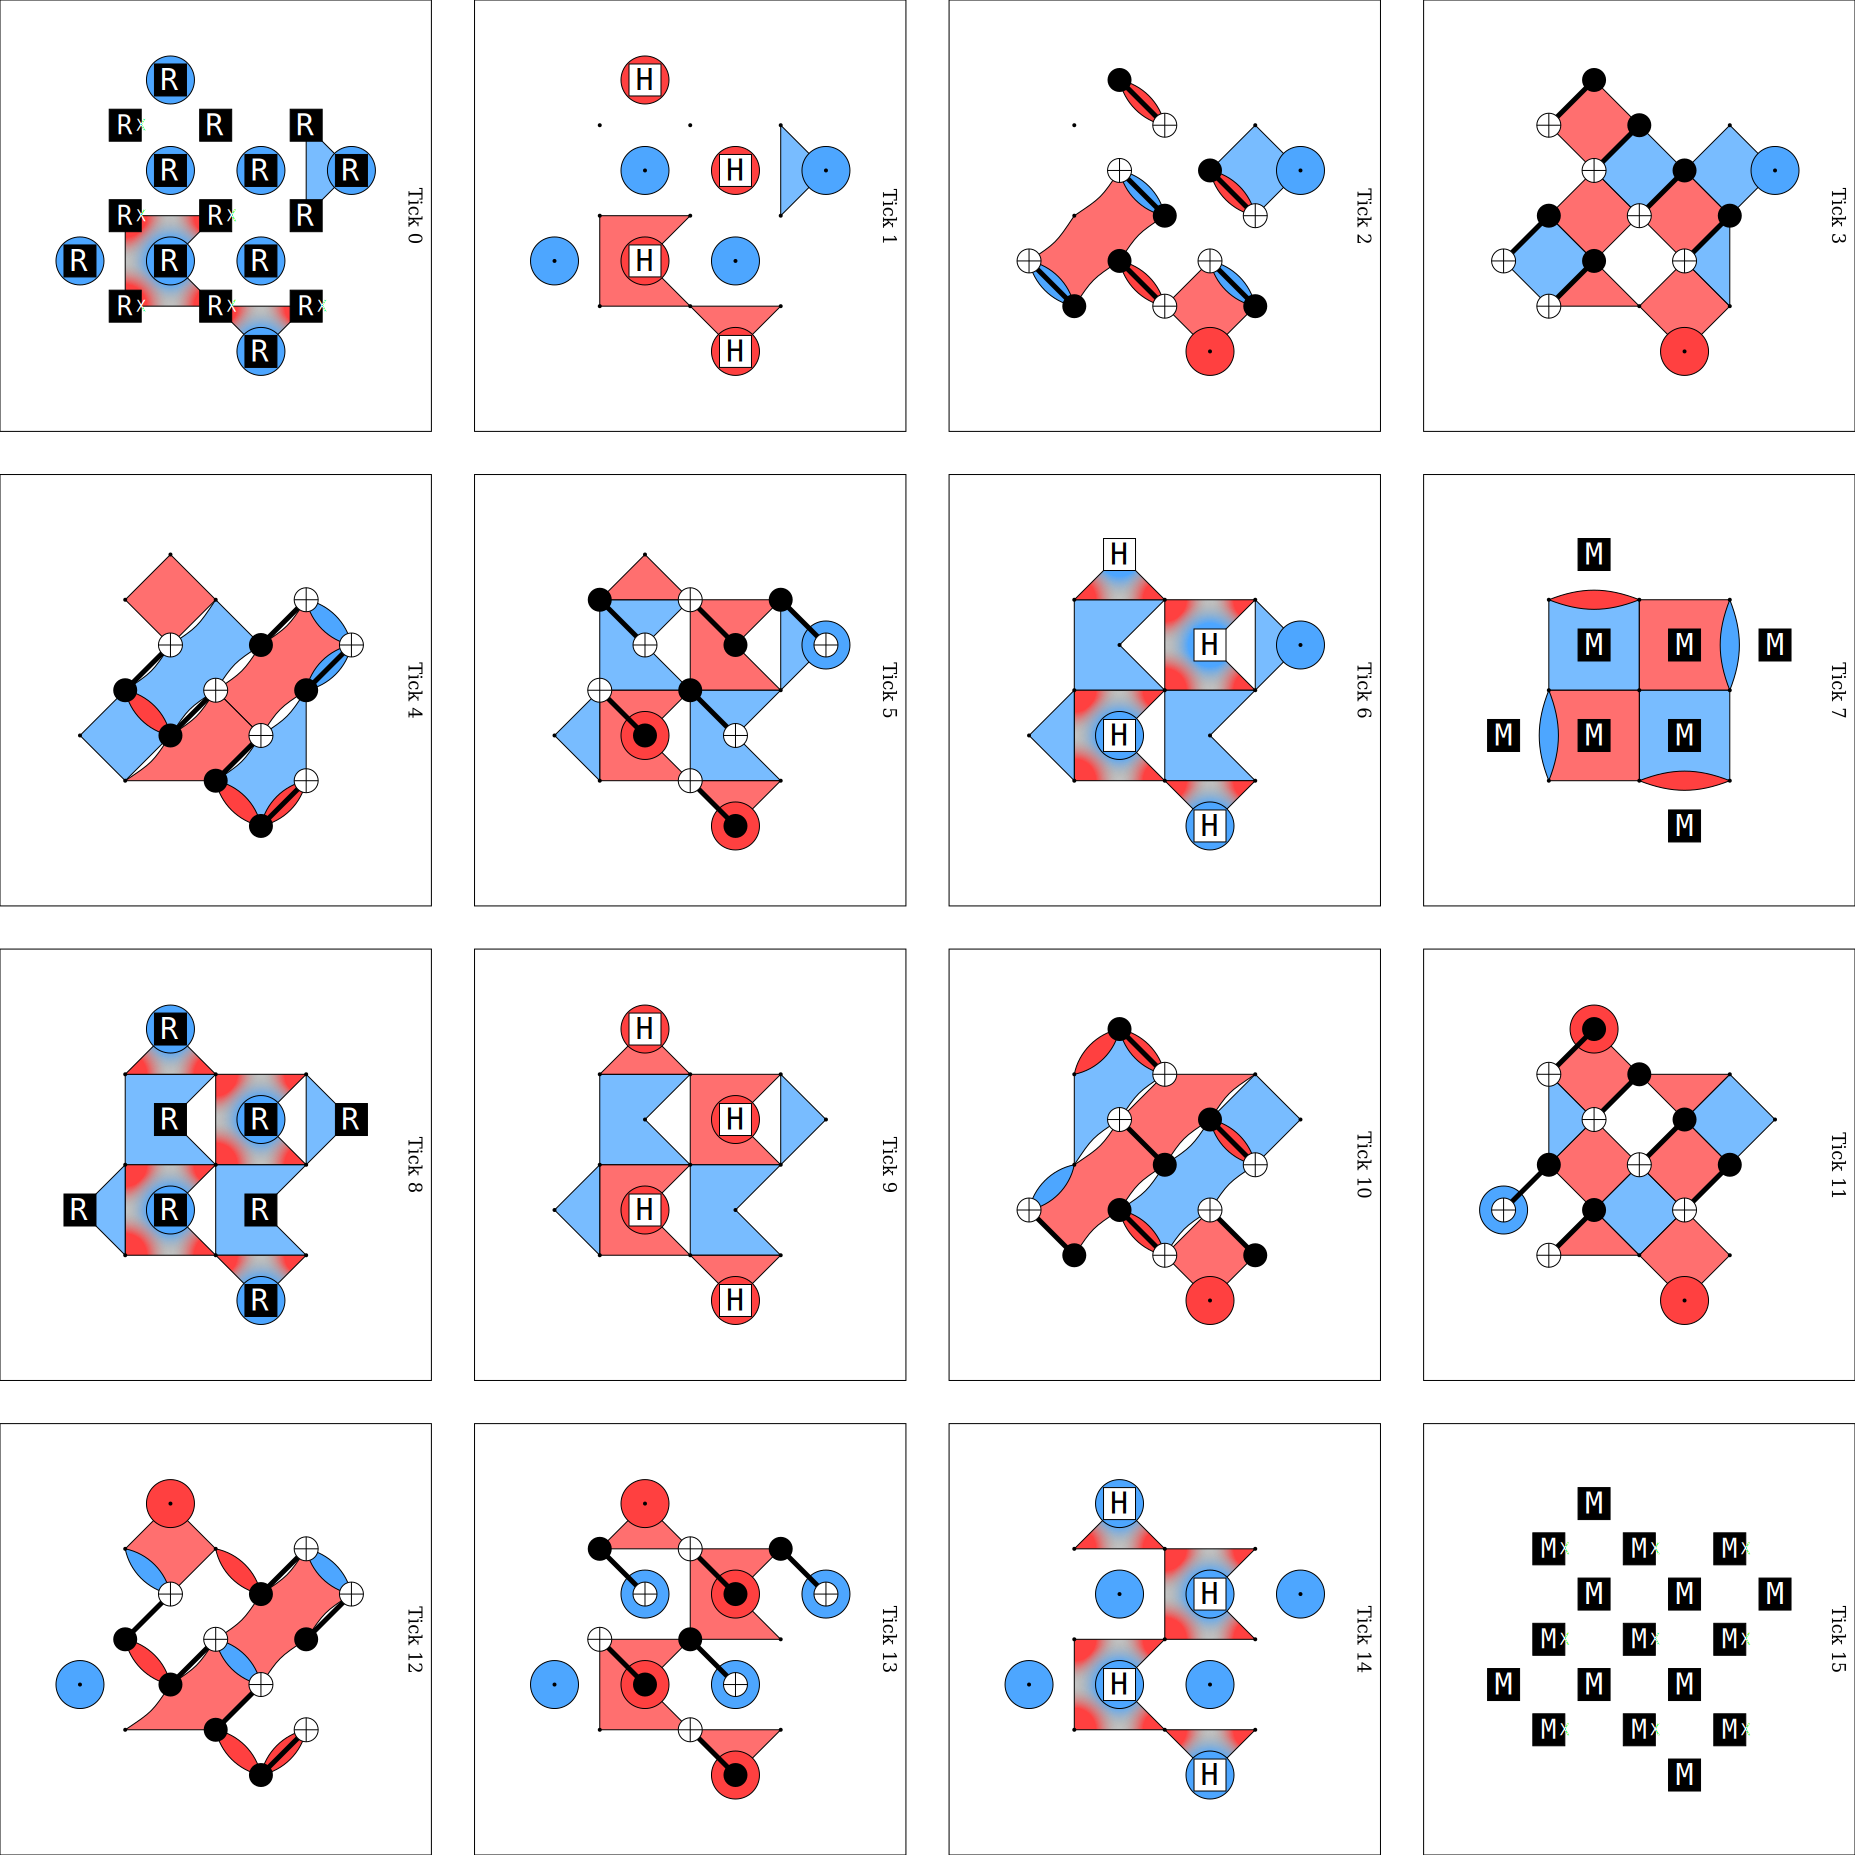

In [4]:
with contextlib.redirect_stdout(io.StringIO()):
    exp_x = StateInjectionExperiment(distance=3, rounds=2, inject_state='X')
    circuit_x = exp_x.build()
print(f"Rotated X: {circuit_x.num_detectors} det, {circuit_x.num_observables} obs")
circuit_x.diagram("detslice-with-ops-svg")

Rotated Y: 14 det, 1 obs


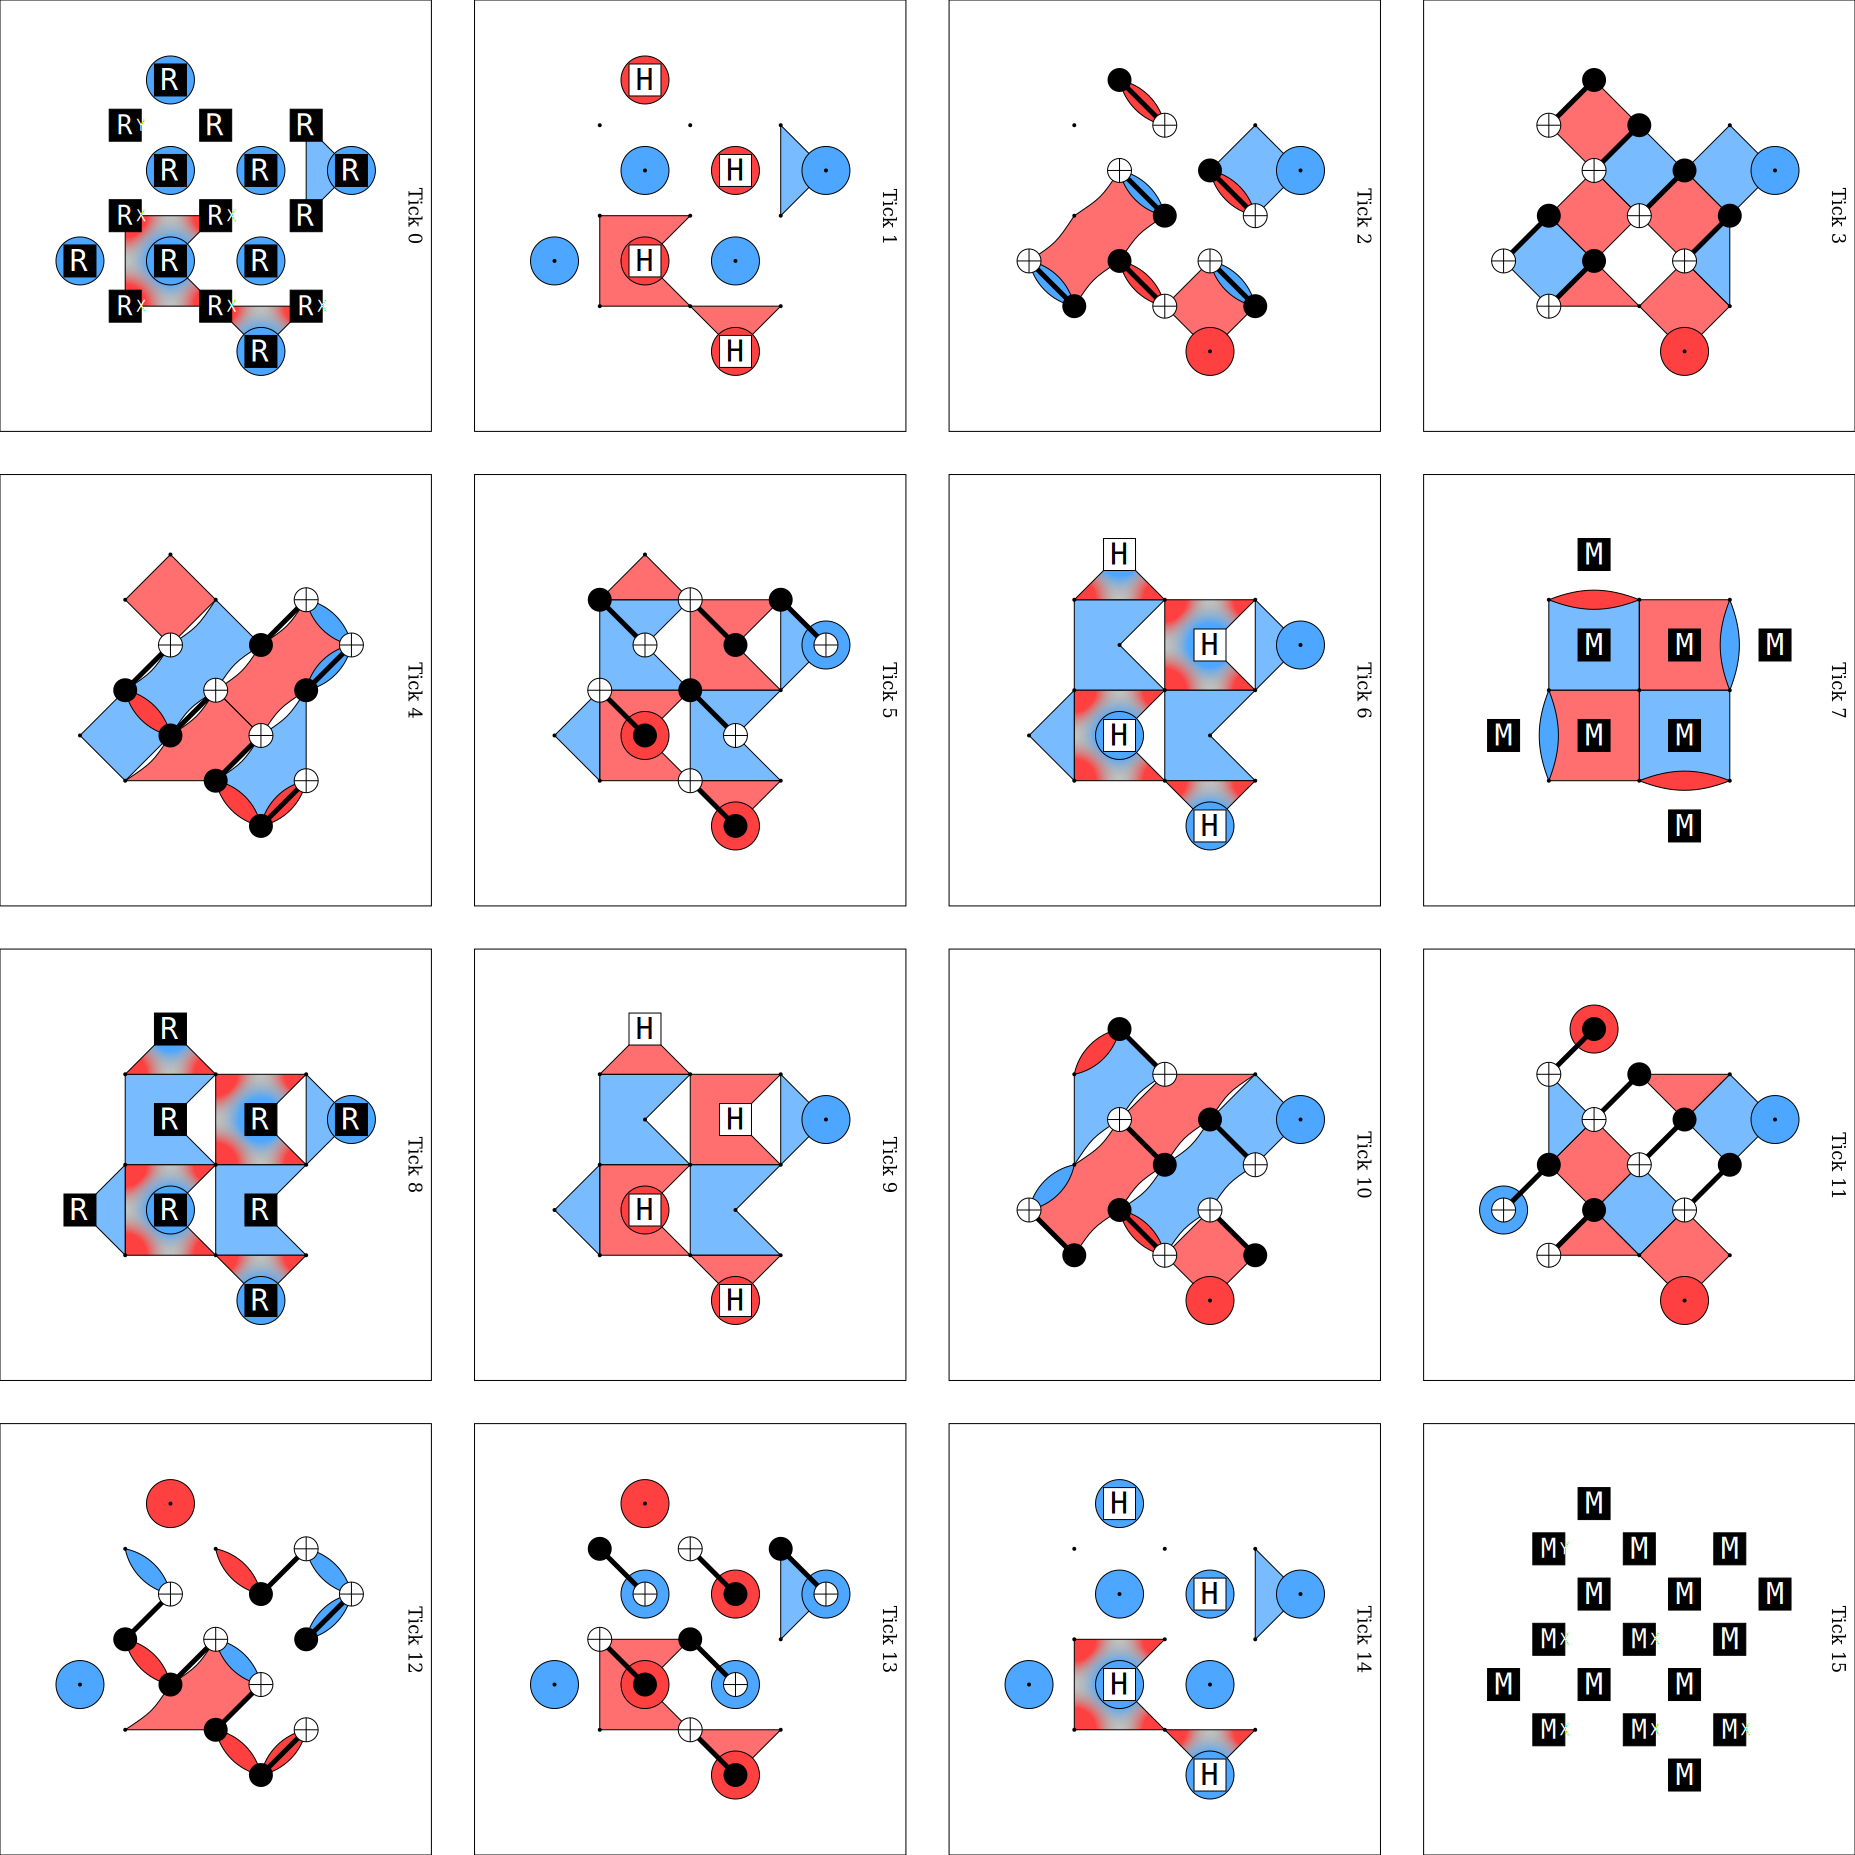

In [5]:
with contextlib.redirect_stdout(io.StringIO()):
    exp_y = StateInjectionExperiment(distance=3, rounds=2, inject_state='Y')
    circuit_y = exp_y.build()
print(f"Rotated Y: {circuit_y.num_detectors} det, {circuit_y.num_observables} obs")
circuit_y.diagram("detslice-with-ops-svg")

In [6]:
circuit_y

stim.Circuit('''
    QUBIT_COORDS(2, 0) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(3, 1) 2
    QUBIT_COORDS(5, 1) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(6, 2) 5
    QUBIT_COORDS(4, 2) 6
    QUBIT_COORDS(1, 3) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(5, 3) 9
    QUBIT_COORDS(0, 4) 10
    QUBIT_COORDS(4, 4) 11
    QUBIT_COORDS(2, 4) 12
    QUBIT_COORDS(1, 5) 13
    QUBIT_COORDS(3, 5) 14
    QUBIT_COORDS(5, 5) 15
    QUBIT_COORDS(4, 6) 16
    RX 7 8 13 14 15
    R 2 3 9
    RY 1
    R 0 4 5 6 10 11 12 16
    TICK[SE_start]
    H 0 6 12 16
    TICK
    CX 0 2 6 9 12 14 8 4 13 10 15 11
    TICK
    CX 0 1 6 8 12 13 2 4 7 10 9 11
    TICK
    CX 6 3 12 8 16 15 7 4 9 5 14 11
    TICK
    CX 6 2 12 7 16 14 1 4 3 5 8 11
    TICK
    H 0 6 12 16
    TICK
    M 0 4 5 6 10 11 12 16
    DETECTOR[post-select](6, 2, 0) rec[-6]
    DETECTOR[post-select](2, 4, 0) rec[-2]
    DETECTOR[post-select](4, 6, 0) rec[-1]
    REPEAT 1 {
        TICK
        R 0 4 5 6 10 11 12 16
        TICK[SE_start]


## 2. Unrotated Surface Code: Z, X, Y Injection (d=3, rounds=2)

Unrotated Z: 22 det, 1 obs


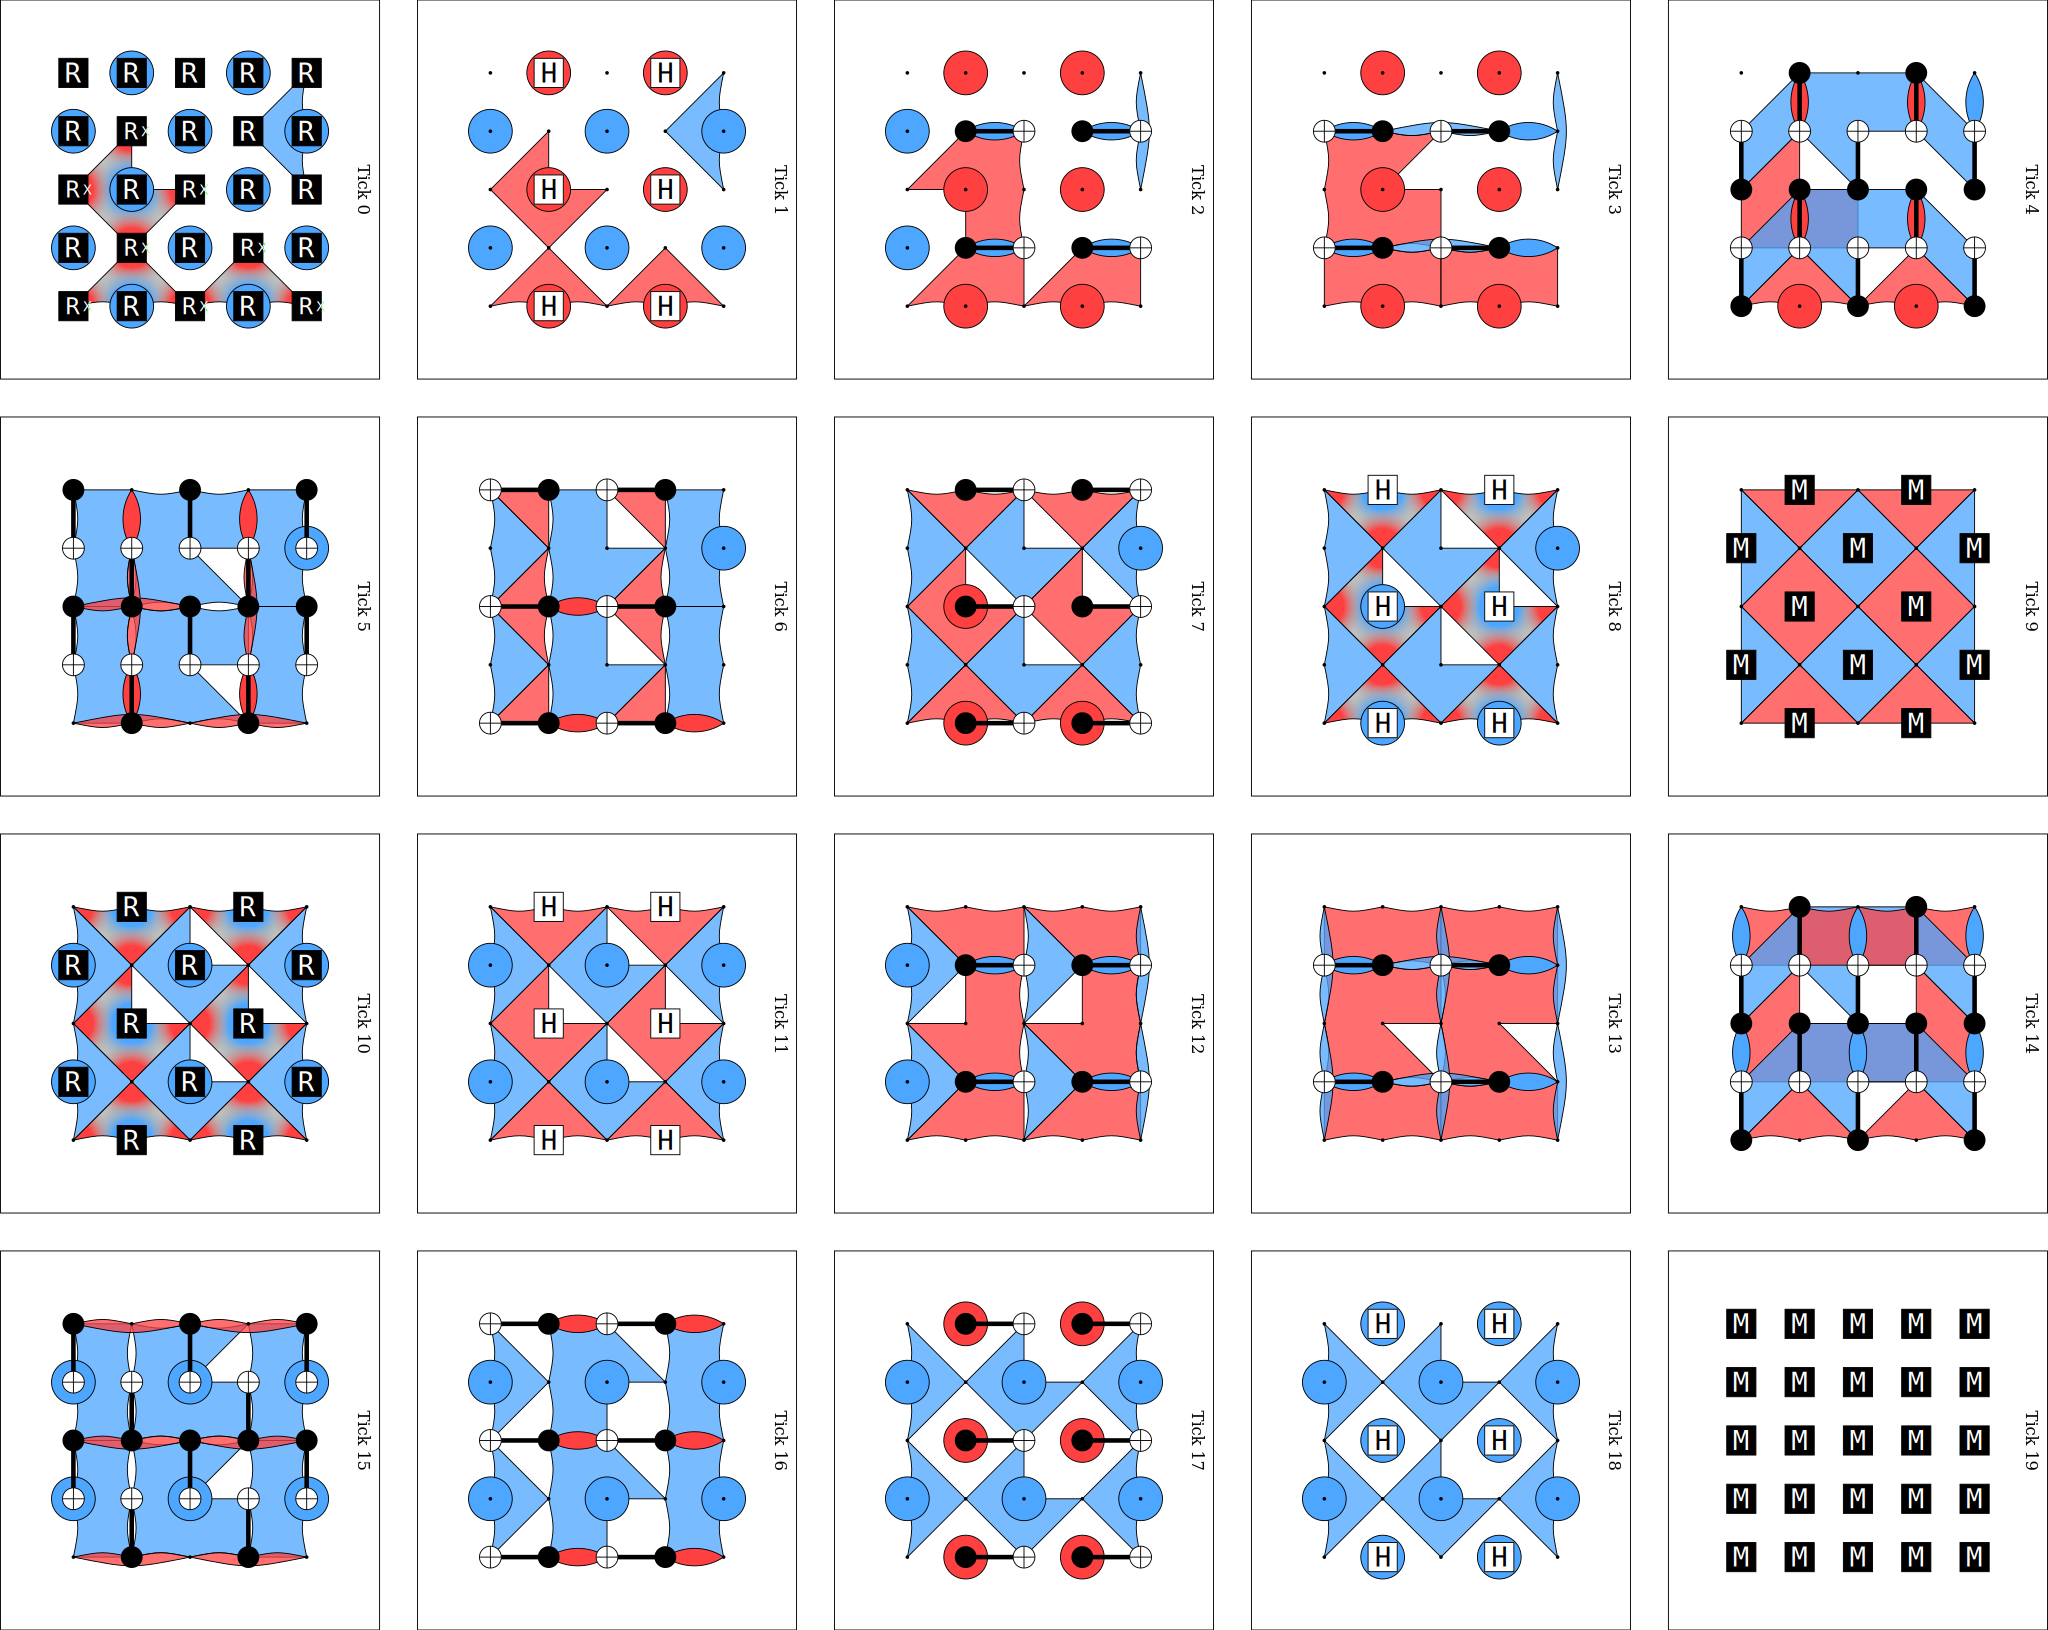

In [7]:
unrot_kwargs = dict(
    code_patch_class=UnrotatedSurfaceCode,
    extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
    op_set_class=UnrotatedSurfaceCodeLogicalOpSet,
)

with contextlib.redirect_stdout(io.StringIO()):
    exp_uz = StateInjectionExperiment(**unrot_kwargs, distance=3, rounds=2, inject_state='Z')
    circuit_uz = exp_uz.build()
print(f"Unrotated Z: {circuit_uz.num_detectors} det, {circuit_uz.num_observables} obs")
circuit_uz.diagram("detslice-with-ops-svg")

In [ ]:
# Unrotated Y injection: noiseless S_DAG → transversal MX
with contextlib.redirect_stdout(io.StringIO()):
    exp_uy = StateInjectionExperiment(**unrot_kwargs, distance=3, rounds=2, inject_state='Y')
    circuit_uy = exp_uy.build()
print(f"Unrotated Y (noiseless S_DAG + MX): {circuit_uy.num_detectors} det, {circuit_uy.num_observables} obs")
circuit_uy.diagram("detslice-with-ops-svg")

## 3. Noiseless Verification

In [ ]:
configs = [
    ("Rotated", {}),
    ("Unrotated", unrot_kwargs),
]
for label, kwargs in configs:
    for state in ['Z', 'X', 'Y']:
        with contextlib.redirect_stdout(io.StringIO()):
            exp = StateInjectionExperiment(**kwargs, distance=3, rounds=2, inject_state=state)
            c = exp.build()
        dem = c.detector_error_model(decompose_errors=True, ignore_decomposition_failures=True)
        sampler = c.compile_detector_sampler()
        det, obs = sampler.sample(shots=1000, separate_observables=True)
        readout = "S_DAG+MX" if (state == "Y" and "Unrotated" in label) else ("unencode+MY" if state == "Y" else f"M{state}")
        print(f"{label} {state} ({readout}): {c.num_detectors} det, {c.num_observables} obs, "
              f"clean={not det.any() and not obs.any()}")

## 4. Decoded Simulation (PyMatching)

Sweep: code = [rotated, unrotated], state = [Z, X, Y], scheme = [full_PS, full_qec, hybrid], d = [3, 5], p = 1e-3.
36 tasks total.

In [ ]:
tasks = []
p = 1e-3
noise = NoiseConfig(p_meas=p, p_reset=p, p_1q=p, p_2q=p, p_idle=p)

code_configs = [
    ("rotated", {}),
    ("unrotated", unrot_kwargs),
]

for code_label, kwargs in code_configs:
    for state in ['Z', 'X', 'Y']:
        for mode in ['full_postselection', 'full_qec', 'hybrid']:
            for d in [3, 5]:
                with contextlib.redirect_stdout(io.StringIO()):
                    exp = StateInjectionExperiment(
                        **kwargs, distance=d, rounds=2,
                        inject_state=state, protocol='corner',
                        post_select_mode=mode, noise_params=noise,
                    )
                    circuit = exp.build()
                tasks.append(ExperimentTask(circuit, json_metadata={
                    "code": code_label, "state": state, "mode": mode, "d": d, "p": p,
                }))

print(f"Built {len(tasks)} tasks")

pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_errors=200, max_shots=1_000_000, num_workers=32, print_progress=True,
)
df = pipeline.run_batch(tasks)
df[["code", "state", "mode", "d", "p", "shots", "post_selected_shots",
    "post_selection_rate", "errors", "logical_error_rate"]]